#Датирование исторических текстов на нидерландском языке (XIII-XIX вв.)

*Часть работы выполнялась в Google Colab (работа с большими объемами данных), часть - в Visual Studio (вспомогательные этапы работы, связанные с загрузкой/записью файлов в локальном хранилище).*

##1. Загрузка библиотек

In [ ]:
#для работы с датафреймами
import pandas as pd

#для сбора корпуса текстов из директории
import os

#для регулярных выражений
import re

#для работы с массивами
import numpy as np

In [ ]:
#для парсинга .xml-файлов
from bs4 import BeautifulSoup

In [ ]:
#для разбивки текста на батчи при подсчете ttr
from itertools import batched

In [ ]:
#для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#для разделения данных на train и test
from sklearn.model_selection import train_test_split

#модели
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

#метрики
from sklearn.metrics import accuracy_score, f1_score, classification_report

#для обеспечения баланса классов при использовании MultinomialNB
from sklearn.utils.class_weight import compute_sample_weight

#энкодер для кодирования таргета и скейлер для масштабирования количественных признаков
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

#для создания ансамблей
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier, AdaBoostClassifier

In [ ]:
#для подсчета корреляционной матрицы
!pip install phik

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 12.0 MB/s eta 0:00:00


In [ ]:
import phik
from phik.report import plot_correlation_matrix

In [ ]:
# для отлеживания процесса обработки данных (прогресс-бар)
from tqdm import tqdm
tqdm.pandas()

##2. Сбор корпуса

Корпус был собран из двух источников:  

* **Digitale Bibliotheek voor de Nederlandse Letteren (DBNL), publiek domein** - база текстов, размещенная на сайте Электронной библиотеки нидерландской литературы; находится в публичном доступе, содержит тексты разных жанров - романы, рассказы, пьесы, поэтические произведения, эссе, научную литературу; тексты датируются XIII-XIX вв.

* **Corpus Middelnederlands (CM)** -  база текстов, написанных на средненидерландском (Middelnederlands) языке; доступна на сайте Института нидерландского языка (Instituut voor de Nederlandse Taal, INT); содержит рассказы, поэтические произведения, пьесы; тексты датируются XIII-XVI вв.

Из-за ограничений оперативной памяти из баз данных взята часть произведений общим объемом в **833 текста**.

Корпус собирался в следующем порядке:  
1) С сайта Электронной библиотеки нидерландской литературы загружена находящаяся в открытом доступе **база текстов** (в формате .txt), а также **метаданные** (в формате .csv) для этой базы, в которой содержатся:  
- уникальный номер и название произведения,  
- автор произведения (при наличии);  
- пол автора (0 - мужчина, 1 - женщина);  
- год издания произведения;  
- жанр произведения;  
- библиотека, в которой хранится экземляр произведения, и др.

2) Тексты произведений собраны в таблицу в формате .csv с двумя колонками - уникальный номер произведения и текст произведения.

3) Таблица с метаданными и таблица с текстами произведений **объединены** (merge) по уникальному номеру произведения.

4) Объединенная таблица **дополнена** текстами из базы текстов, написанных на средненидерландском языке, в той части, в которой этих текстов не было на сайте Электронной библиотеки нидерландской литературы; тексты из базы текстов, написанных на средненидерландском языке, были получены путем парсинга .xml файлов с помощью BeautifulSoup.  

5) Из финальной таблицы удалены **дубликаты** (дубликаты в финальной таблице возникли в связи с тем, что в таблице с метаданными сведения о произведениях хранятся в длинном формате: если у произведения несколько авторов или оно относится к нескольким жанрам, то сведения о нем распределены по нескольким строкам).

*Таблица с метаданными*

In [ ]:
df_metadata = pd.read_csv('/content/titels_pd.csv', sep = '|', skiprows=1, on_bad_lines="skip")

In [ ]:
df_metadata.columns

Index(['ti_id', 'titel', 'vols', 'jaar', 'druk', 'ppn_o', 'bibliotheek',
       'categorie', '_jaar', 'pers_id', 'voornaam', 'voorvoegsel',
       'achternaam', 'jaar_geboren', 'jaar_overlijden', 'geb_datum',
       'overl_datum', 'geb_plaats', 'overl_plaats', 'geb_plaats_code',
       'geb_land_code', 'overl_plaats_code', 'overl_land_code', 'vrouw', 'url',
       'text_url', 'maand', 'genre', 'Unnamed: 28'],
      dtype='object')

*Таблица с текстами*

In [ ]:
list_texts = []
list_ti_ids = []
count = 0

for f in os.listdir():
  if f.endswith('.txt'):
    with open(f'/content/{f}', 'r', encoding='utf-8') as file_by_one:
      list_texts.append(file_by_one.read())
      list_ti_ids.append(f.split('_01.')[0])
#ti_id - уникальные идентификаторы произведений и одновременно названия файлов, за исключением пометки в конце _01

    count += 1

    print(f'{count}')

In [ ]:
df_id_and_text = pd.DataFrame({
    'ti_id': list_ti_ids,
    'text': list_texts
})

In [ ]:
# df_id_and_text.to_csv('df_id_and_text.csv', index=False)

*Объединенная таблица (метаданные и тексты)*

In [ ]:
df_merged = pd.merge(df_id_and_text, df_metadata, on='ti_id', how='inner')

*Дополнение корпуса*

In [ ]:
files = ['roman_van_limborch.xml', 'van_saladijn.xml',  'vierde_martijn.xml', 'der_leken_spieghel.xml', 'vanden_kerstenen_ghelove.xml', 'getijdenboek_van_geert_grote.xml', 'visioenen.xml',  'brieven.xml', 'mengeldichten_hadewijch.xml', 'alexanders_geesten.xml', 'spiegel_historiael__2.xml', 'spiegel_historiael__1_3_4_maerlant.xml', 'spiegel_historiael__5.xml', 'rinclus.xml', 'der_minnen_loep.xml', 'mellibeus.xml', 'vanden_vier_becoringhen.xml', 'vanden_seven_sloten.xml',  'vanden_twaelf_beghinen.xml', 'vanden_blinckenden_steen.xml', 'van_seven_trappen.xml', 'aiol.xml', 'aubri_de_borgengoen.xml', 'boudewijn_van_seborch_fragm_m.xml', 'roman_van_cassamus__lang_1360.xml', 'des_coninx_summe.xml', 'ferguut.xml', 'floovent.xml', 'gwidekijn_van_sassen.xml',  'huge_van_bordeeus_fragm_m.xml', 'roman_van_lancelot.xml', 'lanceloet_en_het_hert_met_de_witte_voet.xml', 'roman_der_lorreinen_fragm_gi.xml', 'loyhier_en_malaert_fragm_g.xml', 'die_dietsche_lucidarius.xml',  'historie_van_malegijs.xml', 'roman_van_moriaen.xml', 'ons_heren_passie.xml', 'vlaamse_rose_fragm_beu.xml',  'segheliin_van_jerusalem.xml', 'tondalus_visioen_hs_n.xml', 'roman_van_torec.xml', 'truwanten.xml', 'valentijn_en_nameloos_fragm_ge.xml',  'van_smeinscen_lede.xml', 'van_den_vos_reynaerde.xml', 'willem_van_oringen.xml']

In [ ]:
list_texts_to_add = []
list_titles = []

for file_name in files:

    with open(f"D:\\Компьютерная лингвистика\\Машинное обучение\\проект\\корпуса\\CorpusMiddelnederlands_1.0\\CorpusMiddelnederlands_1.0\\all\\{file_name}", "r", encoding="utf-8") as file:
        page_n = file.read()
    soup = BeautifulSoup(page_n, 'lxml-xml')
    text = soup.find('text').text
    title = soup.find('title').text
    file_n = file_name.split('.x')[0]

    list_texts_to_add.append(text)
    list_titles.append(title)

    with open(f"D:\\Компьютерная лингвистика\\Машинное обучение\\проект\\корпуса\\txt_add\\{file_n}.txt", "w", encoding="utf-8") as file_w:
        file_w.write(f"{title}")
        file_w.write(f"{text}")

In [ ]:
dict_add_mid_ned = {'list_titels': list_titles,
                    'text': list_texts_to_add }

In [ ]:
df_add = pd.DataFrame(dict_add_mid_ned)

In [ ]:
# df_add.to_csv('D:\\Компьютерная лингвистика\\Машинное обучение\\проект\\additional_texts.csv', index = False)

Поскольку дополнительных текстов было немного (около 50), ti_id (уникальные идентификаторы произведений) были добавлены в таблицу df_add вручную. Это было также необходимо для того, чтобы перепроверить, что добавляемые тексты соотносятся с метаданными о них и не повторяют тексты, которые уже имеются в корпусе.

In [ ]:
df_merged_2 = pd.merge(df_metadata, df_add, on='ti_id', how='inner')

In [ ]:
df_merged_all = pd.concat([df_merged, df_merged_2], ignore_index=True)

In [ ]:
df_merged_all = df_merged_all.drop_duplicates(subset=['ti_id'])

In [ ]:
# df_merged_all.to_csv('/content/cleaned_result_all_855_SHORTER.csv', index = False)

##3. Исследование данных и определение таргета

###3.1. Проверка данных

Посмотрим, какие есть в получившемся датафрейме колонки, а также проверим, что все 833 собранных текста есть в датафрейме и нет пропущенных данных, которые понадобятся при обучении моделей.

In [ ]:
df_merged_all = pd.read_csv('/content/df_merged_CLEANED.csv')

In [ ]:
df_merged_all.shape

(833, 30)

In [ ]:
df_merged_all.columns

Index(['ti_id', 'text', 'titel', 'vols', 'jaar', 'druk', 'ppn_o',
       'bibliotheek', 'categorie', '_jaar', 'pers_id', 'voornaam',
       'voorvoegsel', 'achternaam', 'jaar_geboren', 'jaar_overlijden',
       'geb_datum', 'overl_datum', 'geb_plaats', 'overl_plaats',
       'geb_plaats_code', 'geb_land_code', 'overl_plaats_code',
       'overl_land_code', 'vrouw', 'url', 'text_url', 'maand', 'genre',
       'Unnamed: 28'],
      dtype='object')

In [ ]:
df_merged_all.dtypes
#колонки с годом две: в jaar необязательно числовое значение, может быть написано "примерно 1200 г."
#_jaar - числовое значение

,0
ti_id,object
text,object
titel,object
vols,object
jaar,object
druk,object
ppn_o,object
bibliotheek,object
categorie,int64
_jaar,int64


Самое раннее произведение - 1200 г., самое позднее - 1883 г.

In [ ]:
print(f'Самое раннее произведение датируется {df_merged_all['_jaar'].min()} годом.')
print(f'Самое позднее - {df_merged_all['_jaar'].max()} годом.')

Самое раннее произведение датируется 1200 годом.
Самое позднее - 1883 годом.


In [ ]:
print(f'Группы произведений - {', '.join(df_merged_all['genre'].unique())}.')
print('То есть нон-фикшен, поэзия, литературоведение, проза, литература для детей и подростков, языкознание, пьесы.')

Группы произведений - non-fictie, poëzie, sec - letterkunde, proza, jeugdliteratuur, sec - taalkunde, drama.
То есть нон-фикшен, поэзия, литературоведение, проза, литература для детей и подростков, языкознание, пьесы.


Поэзия - 408 произведений, проза - 141, нон-фикшен - 104, литературоведение - 69, драма - 65, литература для детей и подростков - 25, языкознание - 21.

In [ ]:
df_merged_all['genre'].value_counts(ascending = False)

,count
genre,
poëzie,408
proza,141
non-fictie,104
sec - letterkunde,69
drama,65
jeugdliteratuur,25
sec - taalkunde,21


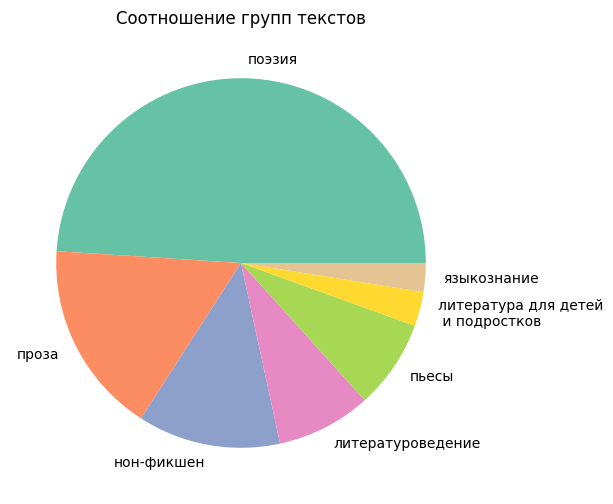

In [ ]:
cmap = plt.get_cmap('Set2')

my_colors = [cmap(i) for i in range(len(df_merged_all))]

df_merged_all['genre'].value_counts().plot(kind='pie',
                                           figsize=(6, 6),
                                           title="Соотношение групп текстов",
                                           colors=my_colors,
                                           wedgeprops={'linewidth': 0},
                                           labels=['поэзия', 'проза', 'нон-фикшен', 'литературоведение', 'пьесы', 'литература для детей\n и подростков', 'языкознание'])
plt.ylabel('')
plt.show()

Можно отметить, что группы произведений обозначены очень специфически (группы неравновесные - род литературы соседствует с конкретными жанрами), при этом среди книг есть сочинения в области **литературоведения и языкознания**.

Книги в области литературоведения и языкознания потенциально могут создавать шум при обучении модели, поскольку в них могут содержаться цитаты из произведений, датируемых другим веком, словарные статьи для языков, отличных от нидерландского.

На данном этапе проекта, однако, было экспериментально решено оставить такие книги в корпусе и посмотреть, будут ли они искажать данные.

Также  можно обратить внимание на то, что в корпусе много **поэтических произведений**. Это необходимо иметь в виду при предобработке текста (например, при удалении лишних переносов строк), а также при обучении модели, если в качестве признаков подаются слова, поскольку поэтические произведения часто специфичны и используют лексику, отличную от обыденной.

In [ ]:
if_dropped = df_merged_all[(df_merged_all['genre'] != 'sec - letterkunde') & (df_merged_all['genre'] != 'sec - taalkunde')]
if_dropped.shape #размер корпуса, если удалить книги по литературоведению и языкознанию (743 текста)

(743, 30)

In [ ]:
df_merged_all.shape #размер корпуса (833 текста)

(833, 30)

In [ ]:
df_merged_all['text'].isna().any()

np.False_

In [ ]:
df_merged_all['_jaar'].isna().any()

np.False_

In [ ]:
df_merged_all['vrouw'].isna().any()

np.False_

###3.2. Отбор данных
Отберем колонки, которыен понадобятся для обучения модели:  
* уникальный идентификатор произведения;
* текст произведения;
* год издания;
* пол автора.

In [ ]:
df_selected = df_merged_all[['ti_id', 'text', '_jaar', 'vrouw']].copy()

###3.3. Выбор таргета

Поскольку язык меняется с течением веков, при этом такие изменения происходят постепенно, в качестве таргета были выбраны **периоды (века)**, в которые было издано произведение.

Конкретные временные периоды были выбраны исходя из:

1) Подходов исследователей нидерландского языка к периодизации его истории, см. в том числе:  

* [Dutch. A linguistic history of Holland and Belgium](https://www.dbnl.org/tekst/dona001dutc02_01/dona001dutc02_01_0004.php), Bruce Donaldson;  
* [Middle Dutch – A short introduction](https://www.researchgate.net/publication/291339060_Middle_Dutch_-_A_short_introduction), Matthias Hüning and Ulrike Vogl (Of Reynaert the Fox: Text and Facing Translation of the Middle Dutch Beast Epic Van den vos Reynaerde, André Bouwman and Bart Besamusca);
* [Negatieverschijnselen en woordvolgorde in de geschiedenis van het Nederlands](https://www.dbnl.org/tekst/hors009nega01_01/hors009nega01_01_0001.php), J.M. van der Horst, Marijke J. van der Wal;
* [Spellinggeschiedenis](https://onzetaal.nl/schatkamer/lezen/taal-en-maatschappij/spelling-geschiedenis), Onze Taal.

2) Самостоятельного анализа текстов, написанных в разное время, их сравнения и выявления признаков, характерых для каждой группы таких текстов.

3) Результатов работы модели с разными временными периодами (изначально была опробована более подробная периодизация с разбивкой не по несколько веков, а по одному веку - до 1600, 1600-1700, 1700-1800, 1800-1900; такая разбивка оказалась неэффективной, поскольку тексты из разных периодов порой были слишком похожи и модель в них путалась).

In [ ]:
for_column_year = [
    (df_selected['_jaar'] < 1500, '1200-1500 гг.'),
    (df_selected['_jaar'] < 1700, '1500-1700 гг.'),
    (df_selected['_jaar'] < 1900, '1700-1900 гг.')
]

In [ ]:
df_selected['eeuw'] = df_selected['_jaar'].case_when(caselist=for_column_year)

In [ ]:
df_selected = df_selected.drop(columns='_jaar')

In [ ]:
df_selected.columns

Index(['ti_id', 'text', 'vrouw', 'eeuw'], dtype='object')

In [ ]:
print(df_selected[df_selected['eeuw'] == '1200-1500 гг.'].tail()) #использован print для скорости отображения таблицы

             ti_id                                               text  vrouw  \
828  _tru001truw01  \n (HIER BEGHINT DIE SOTTERNIE - TRUWANTEN).\n...      0   
829  _val001vale01  \n Ende ginc te Nameloos dat hi mach.\nNu moge...      0   
830  _van004vans01  \n PROLOOG\nAlle die willen wesen vroet\nHoe e...      0   
831  _vos001vosr14  \n VAN DEN VOS REYNAERDE\nWillem, die vele bou...      0   
832  _wil002will01  \n Met sinen knape vor hi sire strate,\nHi hae...      0   

              eeuw  
828  1200-1500 гг.  
829  1200-1500 гг.  
830  1200-1500 гг.  
831  1200-1500 гг.  
832  1200-1500 гг.  


###3.4. Выявление соотношения классов

В данных присутствует **дисбаланс классов**, который в дальнейшем необходимо будет учитывать при обучении модели.
  
1700-1900 гг. - 554 произведения, 1500-1700 гг. - 216, 1200-1500 гг. - 63.

In [ ]:
df_selected['eeuw'].value_counts()

,count
eeuw,
1700-1900 гг.,554
1500-1700 гг.,216
1200-1500 гг.,63


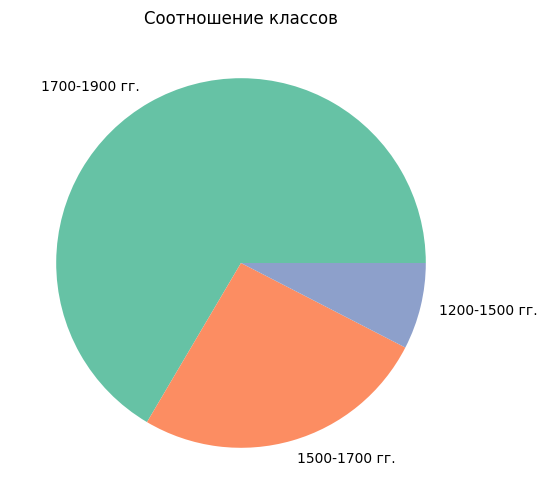

In [ ]:
cmap_2 = plt.get_cmap('Set2')

my_colors_2 = [cmap_2(i) for i in range(len(df_selected))]

df_selected['eeuw'].value_counts().plot(kind='pie',
                                        figsize=(6, 6),
                                        title="Соотношение классов",
                                        colors=my_colors_2,
                                        wedgeprops={'linewidth': 0})
plt.ylabel('')
plt.show()

##4. Формирование признаков (features) для обучения модели

Признаки для дальнейшего обучения модели были отобраны, как и в случае с выбором таргета, с использованием **научных статей** (об особенностях орфографии, лексики и синтаксиса нидерландского языка в разные века), самостоятельного **анализа** текстов и результатов **работы модели** с разным набором признаков.  

Поиск и подсчет признаков в текстах осуществлялся в первую очередь с помощью регулярных выражений, поскольку:  

* обработка (в частности лемматизация, тегирование POS) исторических текстов сопряжена с необходимостью дополнительного лингвистического препроцессинга текстов либо использования специальных предобученных моделей, которые не всегда находятся в открытом доступе;

*  при этом с учетом характера признаков (см. ниже) использование регулярных выражений было наиболее оптимальным способом поиска признаков в текстах и не снижало качество результата работы модели.




###4.1. Конструкция отрицания (ontkenning)

В нидерландском языке, как и в некоторых других языках (английском, немецком, французском), на протяжении его истории менялась конструкция отрицания.

Она прошла путь от единичного отрицания (*ne, en*, до XII в.) к **двусоставному отрицанию** (*en... niet/geen/niemant etc.*) и затем обратно к единичному (*niet/geen/niemand etc.*).

В связи с этой особенностью нидерландского языка было сформулировано предположение, что количество конструкций *en... niet* будет разниться в зависимости от времени издания произведения: в старых произведениях их будет больше, а в более современных - меньше (в современном нидерландском *en... niet* также может встречаться, но в другом значении: *en* теперь означает не отрицание, а союз "и", и в таком значении встречаемость *en... niet* будет ниже).

Функция **clean_text_initial_and_find_negation**:
* предварительно обрабатывает текст (чистит его от лишних знаков);
* делит текст на предложения;
* ищет двусоставное отрицание в предложениях и считает отношение количества предложений с двусоставным отрицанием к общему количеству предложений в тексте.

In [ ]:
def clean_text_initial_and_find_negation(text):
  try:
    clean_text = text.split('onderscheiden van de rest van de tekst door middel van accolades')[1]
  except:
    clean_text = text
  clean_text = re.sub(r'{[=\w\s><\.:-]+}', ' ', clean_text)
  clean_text = re.sub(r'\d', ' ', clean_text)
  clean_text = re.sub(r'[,\\\/""''><;{}\n\t&%$#@*”“‘’()§=:]+', ' ', clean_text)
  clean_text = re.sub(r'\xa0', ' ', clean_text)
  clean_text = re.sub(r'[\[\]]', '', clean_text)
  clean_text = re.sub(r'[\?\!]', '.', clean_text)
  clean_text = re.sub(r'[^\w\s\.]', ' ', clean_text)
  clean_text = re.sub(r'\b[A-Za-z]\b', ' ', clean_text)
  clean_text = re.sub(r'\n+', ' ', clean_text)
  clean_text = re.sub(r' +', ' ', clean_text)
  clean_text = clean_text.lower()

  sentences = clean_text.split('.')

  num_sentences = len(sentences)
  count_negations = 0
  for sentence in sentences:
    negation = re.findall(r'\ben\b \b\w+\b \bniet\b', sentence)
    if len(negation) > 0:
      count_negations +=1
  count_negations_rel = count_negations / num_sentences

  return count_negations_rel

In [ ]:
df_selected['count_negations_rel'] = df_selected['text'].progress_apply(clean_text_initial_and_find_negation)

100%|██████████| 833/833 [02:02<00:00,  6.78it/s]


In [ ]:
print(df_selected.head())

           ti_id                                               text  vrouw  \
0  _sur006179301  \n   \n        \n           \n               S...      0   
1  _nie190nieu01  \n    \n        \n            \n              ...      0   
2  _vad003182901  \n\n\n\nVaderlandsche Letteroefeningen \nJaarg...      0   
3  _noo007184101  \n    \n        \n            \n              ...      0   
4  _qua001quae01  \n   \n        \n           \n               D...      0   

            eeuw  count_negations_rel  
0  1700-1900 гг.             0.000254  
1  1500-1700 гг.             0.009195  
2  1700-1900 гг.             0.003253  
3  1700-1900 гг.             0.001327  
4  1500-1700 гг.             0.018233  


###4.2. Особенности орфографии

####4.2.1. Предобработка текста

Для дальнейшей работы с датафреймом тексты предобрабатываются:
* удаляется "шапка" текстов с их названием и выходными данными;
* исключаются специальные символы, множественные и неразрывные пробелы, цифры;
* слова восстанавливаются до их полного написания путем удаления квадратных скобок (обычно в квадратных скобках дописываются слова, которые были неразборчивы в оригинале, например *in d[en] Haag*).

Функция **clean_text** частично повторяет **clean_text_initial_and_find_negation**, но содержит свои особенности, поскольку в дальнейшем текст не будет делиться на предложения (в частности, точки в функции clean_text удаляются, в отличие от clean_text_initial_and_find_negation, где они используются для разбивки на предложения с помощью split).

In [ ]:
def clean_text(text):
  try:
    clean_text = text.split('onderscheiden van de rest van de tekst door middel van accolades')[1]
  except:
    clean_text = text
  clean_text = re.sub(r'{[=\w\s><\.:-]+}', ' ', clean_text)
  clean_text = re.sub(r'\d', ' ', clean_text)
  clean_text = re.sub(r'\xa0', ' ', clean_text)
  clean_text = re.sub(r'[\[\]]', '', clean_text)
  clean_text = re.sub(r'[^\w\s]', ' ', clean_text)
  clean_text = re.sub(r'\b[A-Za-z]\b', ' ', clean_text)
  clean_text = re.sub(r'\n+', ' ', clean_text)
  clean_text = re.sub(r' +', ' ', clean_text)
  clean_text = clean_text.lower()
  return clean_text

In [ ]:
df_selected_clean = df_selected.copy()

In [ ]:
df_selected_clean['text'] = df_selected_clean['text'].progress_apply(clean_text)

100%|██████████| 833/833 [01:32<00:00,  9.03it/s]


In [ ]:
print(df_selected_clean['text'].iloc[5][204:279])

beeld altoos voor myn daaglyks zien ik uwen schaduw en des nachts droom ik 


####4.2.2. Поиск паттернов

Среди особенностей орфографии в качестве паттернов для поиска и подсчета в текстах были выбраны следующие особенности.

| <font size="2.5"> Буквы (сочетание букв) </font> | <font size="2.5"> Пояснение </font> | <font size="2.5"> Пример </font>|
| -------- | -------- | -------- |
| <font size="3"> y </font> | <font size="3"> заменяла в старых текстах дифтонг ij </font> | <font size="3"> myn = mijn </font> |
| <font size="3"> ae </font> | <font size="3"> обозначало долгую a </font> | <font size="3"> jaer = jaar </font> |
| <font size="3"> ck </font> | <font size="3"> с течением времени заменено на k </font> | <font size="3"> oock = ook </font> |
| <font size="3"> gh </font> | <font size="3"> стало обозначаться g </font> | <font size="3"> ghenoech = genoeg </font> |
| <font size="3"> sch </font> | <font size="3"> во многих случаях заменено на s </font> | <font size="3"> mensch = mens </font> |
| <font size="3"> z </font> | <font size="3"> z почти не использовалась </font> | <font size="3"> seer = zeer </font> |
| <font size="3"> nt </font> | <font size="3"> t писалось как слышится </font> | <font size="3"> hant = hand </font> |
| <font size="3"> kw </font> | <font size="3"> использовалось сочетание qu </font> | <font size="3"> quam = kwam </font> |
| <font size="3"> aa, ee, oo </font> | <font size="3"> заменены в открытом слоге на a, e, o </font> | <font size="3"> heeten = heten </font> |
| <font size="3"> vv </font> | <font size="3"> заменяло при печати w </font> | <font size="3"> vvy = wij </font> |

Функция **count_patterns** принимает на вход текст и паттерн, считает количество паттернов в тексте и выдает отношение количества паттернов в тексте к общему количеству символов (без пробелов) в тексте.

In [ ]:
def count_patterns(text_to_pr, pattern):
  count_absolute = len(re.findall(fr'{pattern}', text_to_pr))
  symbols = re.sub(' ', '', text_to_pr)
  count_all = len(symbols)
  count_relative = count_absolute / count_all
  return count_relative

In [ ]:
df_selected_patterns = df_selected_clean.copy()

In [ ]:
patterns = ['y', 'ae', 'ck', 'gh', 'sch', 'z', 'nt ', 'kw', 'aa', 'ee', 'oo', 'vv']

In [ ]:
for patt in tqdm(patterns):
  df_selected_patterns[patt] = df_selected_patterns['text'].apply(lambda x: count_patterns(text_to_pr = x, pattern = patt))

100%|██████████| 12/12 [03:11<00:00, 15.97s/it]


In [ ]:
print(df_selected_patterns.head())

           ti_id                                               text  vrouw  \
0  _sur006179301   surinaamsche staatkundige almanach voor den j...      0   
1  _nie190nieu01   nieuw iaar lieden wt ghegheven by de nederduy...      0   
2  _vad003182901   boekbeschouwing leerredenen ter verklaring va...      0   
3  _noo007184101   de noordstar tydschrift voor letteren kunsten...      0   
4  _qua001quae01   der ix quaesten warachtighe historien als van...      0   

            eeuw  count_negations_rel         y        ae        ck        gh  \
0  1700-1900 гг.             0.000254  0.011270  0.000172  0.000561  0.000338   
1  1500-1700 гг.             0.009195  0.019882  0.012315  0.009830  0.014949   
2  1700-1900 гг.             0.003253  0.000411  0.000174  0.000075  0.000558   
3  1700-1900 гг.             0.001327  0.017874  0.013247  0.000266  0.000500   
4  1500-1700 гг.             0.018233  0.010014  0.009456  0.005066  0.007953   

        sch         z       nt         kw   

Можно посмотреть предварительно распределение паттернов по классам, для наглядности. В дальнейшем все паттерны будут подсчитаны в рамках корреляционной матрицы.

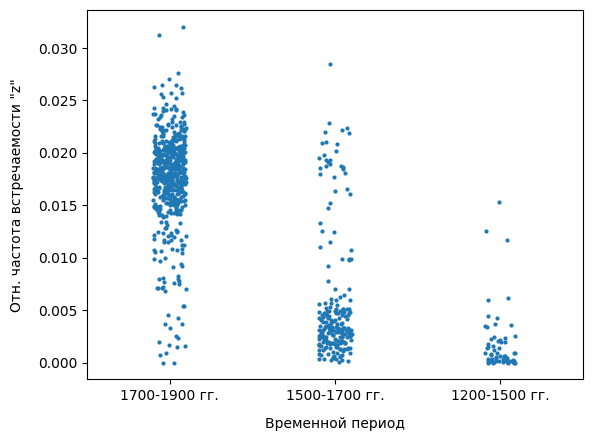

In [ ]:
sns.stripplot(data=df_selected_patterns, x='eeuw', y='z', jitter=True, size = 3)
plt.ylabel('Отн. частота встречаемости "z"', labelpad=10)
plt.xlabel('Временной период', labelpad=10)
plt.show()

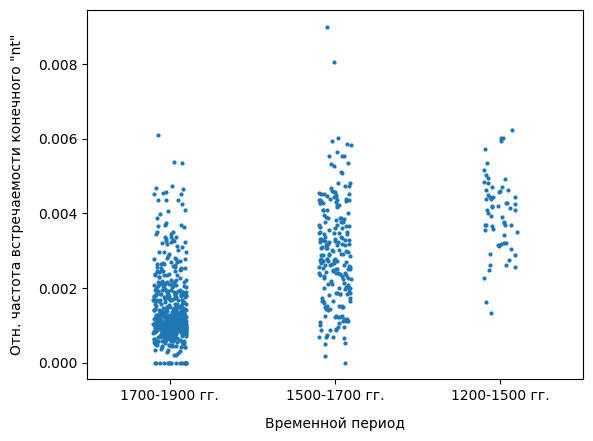

In [ ]:
sns.stripplot(data=df_selected_patterns, x='eeuw', y='nt ', jitter=True, size = 3)
plt.ylabel('Отн. частота встречаемости конечного "nt"', labelpad=10)
plt.xlabel('Временной период', labelpad=10)
plt.show()

####------------------*Анализ выбросов данных*------------------
Анализ выбросов данных по паттернам на одном из первичных этапов работы с корпусом текстов помог выявить тексты, которые необходимо из него удалить.

Так, например, в случае с *nt* оказалось несколько документов, датируемых 1700-1900 гг., в которых *nt*, вопреки общей тенденции, очень часто встречается (см. график **ниже** - это график встречаемости *-nt* на одном из первичных этапов очистки корпуса).


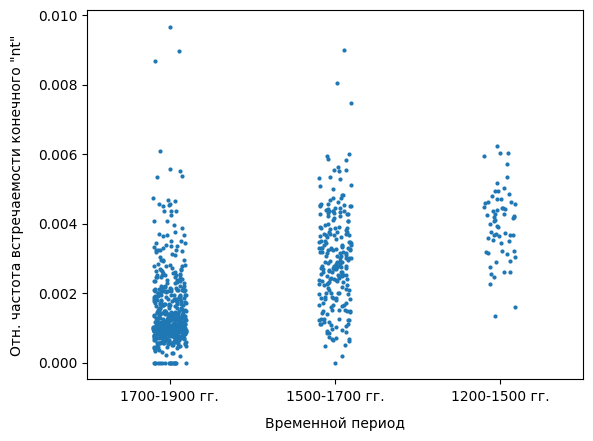

Если отсортировать таблицу, то наряду с документам, для которых больше количество *nt* является просто особенностью, можно обнаружить литературу на французском языке, поскольку для французского это буквосочетание весьма характерно (*souvent*, *dont*, *comment*, etc.).

In [ ]:
df_selected_patterns[df_selected_patterns['nt '] > 0.008]

,ti_id,text,vrouw,eeuw,count_negations_rel,y,ae,ck,gh,sch,z,nt,kw,aa,ee,oo,vv
118,_twe015twee01,twee iournalen het eerste gehouden by de seve...,0,1500-1700 гг.,0.012461,0.020972,0.012820,0.007852,0.006552,0.003284,0.002451,0.009002,0.000033,0.000000,0.019789,0.010536,0.0
438,knep001mesl01,mes loisirs imprimerie de schinkel mes loisir...,0,1700-1900 гг.,0.000000,0.001472,0.000224,0.000000,0.000012,0.000025,0.001995,0.008967,0.000000,0.000037,0.000137,0.000062,0.0
577,hout001open01,\t \t\t \t\t openingsgedicht album amicorum \...,0,1500-1700 гг.,0.166667,0.000000,0.010743,0.000895,0.000000,0.004476,0.015219,0.008057,0.000000,0.000000,0.004476,0.007162,0.0
634,knep001frag01,fragments de correspondance fragments de corr...,0,1700-1900 гг.,0.000000,0.002838,0.000000,0.000000,0.000000,0.000035,0.001542,0.009670,0.000000,0.000000,0.000070,0.000000,0.0
636,knep001lere01,ère critique ou art et le culte ère critique ...,0,1700-1900 гг.,0.000000,0.002845,0.000044,0.000067,0.000044,0.000067,0.000734,0.008692,0.000000,0.000067,0.000156,0.000067,0.0


Встает вопрос, как такие документы идентифицировать. Логичной идеей представляется применить средства для определения языка на названиях произведений либо на их тексте и попытаться найти тексты только на нидерландском языке.   

Однако здесь вновь возникает задача идентификации не просто языка, а языка в определенную историческую эпоху. На HuggingFace есть модели, которые умеют нормализовать исторические тексты на нидерландском под современные, корректируя его спеллинг (после чего можно было бы применить langdetect), но они обычно ориентированы на конкретную эпоху - в частности, на 19 век ([AWolters/ByT5_DutchSpellingNormalization](https://huggingface.co/AWolters/ByT5_DutchSpellingNormalization)). А в корпусе по проекту тексты разных веков.  

Обучение модели распознавать языки на различных этапах их развития может быть отдельным проектом. В рамках моего проекта на данном этапе попробуем воспользоваться средством для распознавания языка, которое работает с современными языками. Как можно увидеть ниже, обычный langdetect смог выявить некоторые тексты, написанные не на нидерландском языке (или с высокой примесью другого языка, как в случае нидерландско-немецкого словаря). Поскольку даже без исключения данных текстов модели давали относительно высокие метрики, остановимся пока на использовании **langdetect**, а также дополнительно **lingua-language-detector**.

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 17.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=aede7d028a6dc473edff978eceac8fb660bec82b62d8e244825cc6f1ebfcd345
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
from langdetect import detect

In [ ]:
df_selected_patterns['lang'] = df_selected_patterns['text'].progress_apply(detect)

100%|██████████| 853/853 [01:19<00:00, 10.72it/s]


In [ ]:
not_dutch = df_selected_patterns[df_selected_patterns['lang'] != 'nl']

In [ ]:
not_dutch.shape

(17, 18)

In [ ]:
not_dutch

,ti_id,text,vrouw,eeuw,count_negations_rel,y,ae,ck,gh,sch,z,nt,kw,aa,ee,oo,vv,lang
28,_nie243nied01,hoerdt moeder liebste moeder mein hoerdt moed...,0,1500-1700 гг.,0.000000,0.005355,0.003224,0.002521,0.002410,0.006236,0.010108,0.000614,0.000000,0.000011,0.000089,0.000011,0.000000,de
87,_thr001thro01,tres illustre seigneur messire louys de mongo...,0,1500-1700 гг.,0.000000,0.010775,0.004596,0.003373,0.006238,0.001582,0.005880,0.007462,0.000000,0.001761,0.004208,0.003582,0.001134,fr
324,_typ001typu01,afbeelding \t quàm sordet mihi terra dum coel...,0,1500-1700 гг.,0.001138,0.005014,0.008819,0.000736,0.002156,0.000649,0.000859,0.002840,0.000000,0.000018,0.001823,0.001245,0.000018,ca
438,knep001mesl01,mes loisirs imprimerie de schinkel mes loisir...,0,1700-1900 гг.,0.000000,0.001472,0.000224,0.000000,0.000012,0.000025,0.001995,0.008967,0.000000,0.000037,0.000137,0.000062,0.000000,fr
460,hugo001piad01,sanctissimo nostro vrbano octavo pontifici ma...,0,1500-1700 гг.,0.000000,0.001232,0.008693,0.000000,0.000000,0.000005,0.000126,0.003390,0.000000,0.000008,0.000041,0.000014,0.000005,ca
481,lefr001outa01,advertisement by the editor courteous reader ...,0,1700-1900 гг.,0.000000,0.019788,0.000003,0.000861,0.001871,0.000369,0.000724,0.002513,0.000010,0.000013,0.003088,0.001865,0.000000,en
528,juni002bata01,hadriani ivnii hornani medici batavia in qua ...,0,1500-1700 гг.,0.000000,0.001239,0.008723,0.000085,0.000014,0.000055,0.000220,0.003386,0.000001,0.000003,0.000092,0.000030,0.000012,it
558,holl015obit01,\t \t \t \t\t\tin obitum clarissimi et doctis...,0,1700-1900 гг.,0.000000,0.001192,0.000000,0.000000,0.000000,0.000397,0.000000,0.005562,0.000000,0.000000,0.000397,0.000000,0.000000,ca
576,marr006jano01,\t \t \t \t\t \t\t\t\tjano davidi pasteur et ...,0,1700-1900 гг.,0.000000,0.001842,0.013812,0.000000,0.000000,0.000000,0.000000,0.005525,0.000000,0.000921,0.000921,0.000000,0.000000,ca
634,knep001frag01,fragments de correspondance fragments de corr...,0,1700-1900 гг.,0.000000,0.002838,0.000000,0.000000,0.000000,0.000035,0.001542,0.009670,0.000000,0.000000,0.000070,0.000000,0.000000,fr


Для сравнения был также использован **lingua-language-detector**. Он выявил несколько больше текстов, написанных не на нидерландском языке, но не всегда верно (отчасти потому, что в этих текстах есть небольшие вставки, например, на латинском языке).

In [ ]:
!pip install lingua-language-detector

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 MB 6.3 MB/s eta 0:00:00


In [ ]:
from lingua import Language, LanguageDetectorBuilder

In [ ]:
languages = [Language.ENGLISH,
             Language.FRENCH,
             Language.GERMAN,
             Language.DUTCH,
             Language.SPANISH,
             Language.LATIN,
             Language.CATALAN,
             Language.ITALIAN,
             Language.PORTUGUESE,
             Language.AFRIKAANS,
             Language.INDONESIAN,
             Language.BASQUE]

In [ ]:
detector = LanguageDetectorBuilder.from_languages(*languages).build()

In [ ]:
df_selected_patterns['lang_2'] = df_selected_patterns['text'].progress_apply(detector.detect_language_of)

100%|██████████| 853/853 [08:04<00:00,  1.76it/s]


In [ ]:
not_dutch_2 = df_selected_patterns[df_selected_patterns['lang_2'] != Language.DUTCH]

In [ ]:
not_dutch_2.shape

(39, 19)

In [ ]:
not_dutch_2.head()

,ti_id,text,vrouw,eeuw,count_negations_rel,y,ae,ck,gh,sch,z,nt,kw,aa,ee,oo,vv,lang,lang_2
10,_mis002miss01,missen en gezangen utrecht by johhannes schel...,0,1700-1900 гг.,0.000000,0.000204,0.004616,0.000000,0.000111,0.001223,0.006988,0.002799,0.000204,0.005876,0.005079,0.005969,0.000000e+00,nl,Language.LATIN
17,_nie004nieu01,aen de ionghe dochters van nederlant ghy soet...,0,1500-1700 гг.,0.027529,0.021428,0.015179,0.008499,0.016908,0.004770,0.004423,0.005853,0.000083,0.000035,0.013311,0.012554,3.617628e-03,nl,Language.LATIN
87,_thr001thro01,tres illustre seigneur messire louys de mongo...,0,1500-1700 гг.,0.000000,0.010775,0.004596,0.003373,0.006238,0.001582,0.005880,0.007462,0.000000,0.001761,0.004208,0.003582,1.134159e-03,fr,Language.LATIN
91,_tij008187601,de tijdspiegel de tijdspiegel eerste deel gra...,0,1700-1900 гг.,0.004153,0.000638,0.000151,0.000148,0.000393,0.005933,0.016241,0.001039,0.000428,0.013171,0.015420,0.011510,2.935603e-07,nl,Language.LATIN
192,_vad004vade03,een rymwerk van jan van ruysbroeck het fragme...,0,1700-1900 гг.,0.004903,0.010202,0.010891,0.002875,0.005388,0.004677,0.007193,0.002552,0.000210,0.000227,0.012598,0.007333,4.857120e-06,nl,Language.LATIN


In [ ]:
list_1 = not_dutch['ti_id'].tolist()
list_2 = not_dutch_2['ti_id'].tolist()

In [ ]:
result = [item for item in list_2 if item not in list_1]

In [ ]:
print(result)

['_mis002miss01', '_nie004nieu01', '_tij008187601', '_vad004vade03', '_pri008prie01', 'make001troo02', 'kram004koni01', 'jonc006rose01', 'nerr001voor01', 'moon005sede01', 'heyn002spie01', 'kram004nieu01', 'kram011leve01', 'jonc006hede01', 'houw001para01', 'jenn003ghee01', 'leen001thea01', 'heyn003embl03', 'juni001schi01', 'meij001lmei01', 'make001denl02', 'japi001frie02', 'krie024bata02', 'maer002spie02']


Финальный список values_to_drop проверен вручную - путем просмотра текстов, которые выявили langdetect и lingua-language-detector, и отсеивания из корпуса текстов не на нидерландком языке.

In [ ]:
values_to_drop = ['_mis002miss01', '_nie004nieu01', '_tij008187601', '_vad004vade03', '_pri008prie01', 'make001troo02', 'jonc006rose01', 'nerr001voor01', 'moon005sede01', 'heyn002spie01', 'kram011leve01', 'jonc006hede01', 'houw001para01', 'jenn003ghee01', 'leen001thea01', 'juni001schi01', 'meij001lmei01',  'make001denl02', 'japi001frie02', 'krie024bata02', 'maer002spie02']

In [ ]:
not_dutch_2_corrected = not_dutch_2[~not_dutch_2['ti_id'].isin(values_to_drop)]

In [ ]:
not_dutch_2_corrected.head()

,ti_id,text,vrouw,eeuw,count_negations_rel,y,ae,ck,gh,sch,z,nt,kw,aa,ee,oo,vv,lang,lang_2
87,_thr001thro01,tres illustre seigneur messire louys de mongo...,0,1500-1700 гг.,0.000000,0.010775,0.004596,0.003373,0.006238,0.001582,0.005880,0.007462,0.000000,0.001761,0.004208,0.003582,0.001134,fr,Language.LATIN
324,_typ001typu01,afbeelding \t quàm sordet mihi terra dum coel...,0,1500-1700 гг.,0.001138,0.005014,0.008819,0.000736,0.002156,0.000649,0.000859,0.002840,0.000000,0.000018,0.001823,0.001245,0.000018,ca,Language.LATIN
438,knep001mesl01,mes loisirs imprimerie de schinkel mes loisir...,0,1700-1900 гг.,0.000000,0.001472,0.000224,0.000000,0.000012,0.000025,0.001995,0.008967,0.000000,0.000037,0.000137,0.000062,0.000000,fr,Language.FRENCH
448,kram004koni01,das königliche hoch nider teutsch und nider h...,0,1700-1900 гг.,0.000000,0.009152,0.000237,0.003739,0.000434,0.011658,0.013499,0.001162,0.000023,0.008840,0.008663,0.005413,0.000000,nl,Language.GERMAN
460,hugo001piad01,sanctissimo nostro vrbano octavo pontifici ma...,0,1500-1700 гг.,0.000000,0.001232,0.008693,0.000000,0.000000,0.000005,0.000126,0.003390,0.000000,0.000008,0.000041,0.000014,0.000005,ca,Language.LATIN


In [ ]:
set_to_drop = set(not_dutch['ti_id'].tolist() + not_dutch_2_corrected['ti_id'].tolist())

In [ ]:
len(set_to_drop)

20

In [ ]:
print(set_to_drop)

{'leuv001amor01', 'kram004grun01', 'leuv001thea01', 'marr006jano01', 'kram004koni01', 'kirc010holl01', 'lefr001outa01', 'mijl001ling01', 'knep001mesl01', 'kram004nieu01', 'heyn003embl03', 'huyg001mome02', 'knep001frag01', '_thr001thro01', 'hugo001piad01', 'juni002bata01', '_nie243nied01', 'holl015obit01', 'knep001lere01', '_typ001typu01'}


In [ ]:
df_merged_all = df_merged_all[~df_merged_all['ti_id'].isin(set_to_drop)]

In [ ]:
df_merged_all.shape

(833, 17)

In [ ]:
# df_merged_all.to_csv('df_merged_all_WITHOUT_NOT_DUTCH.csv', index = False)

###4.3. Особенности лексики и грамматики

####4.3.1. Разбивка текстов на токены

Для поиска лексических и грамматических признаков в текстах тексты были разбиты на наивные токены.  

Функция **naive_tokens** делит текст на токены по пробелу и отбирает среди них в окончательный список токены длиной более 1 символа.

In [ ]:
def naive_tokens(text):
  tokens = text.split()
  clean_tokens = []
  for i in tokens:
    if len(i) > 1:
      clean_tokens.append(i)
  return clean_tokens

In [ ]:
df_selected_patterns_tokens = df_selected_patterns.copy()

In [ ]:
df_selected_patterns_tokens['tokens'] = df_selected_patterns_tokens['text'].progress_apply(naive_tokens)

100%|██████████| 833/833 [00:15<00:00, 53.01it/s] 


In [ ]:
print(df_selected_patterns_tokens.head())

           ti_id                                               text  vrouw  \
0  _sur006179301   surinaamsche staatkundige almanach voor den j...      0   
1  _nie190nieu01   nieuw iaar lieden wt ghegheven by de nederduy...      0   
2  _vad003182901   boekbeschouwing leerredenen ter verklaring va...      0   
3  _noo007184101   de noordstar tydschrift voor letteren kunsten...      0   
4  _qua001quae01   der ix quaesten warachtighe historien als van...      0   

            eeuw  count_negations_rel         y        ae        ck        gh  \
0  1700-1900 гг.             0.000254  0.011270  0.000172  0.000561  0.000338   
1  1500-1700 гг.             0.009195  0.019882  0.012315  0.009830  0.014949   
2  1700-1900 гг.             0.003253  0.000411  0.000174  0.000075  0.000558   
3  1700-1900 гг.             0.001327  0.017874  0.013247  0.000266  0.000500   
4  1500-1700 гг.             0.018233  0.010014  0.009456  0.005066  0.007953   

        sch         z       nt         kw   

####4.3.2. Подсчет TTR (type-token ratio)

Поскольку раньше в нидерландском языке было больше падежных форм и форм глаголов, было сделано предположение, что **TTR** при подсчете словоформ на старых текстах может быть выше, чем на более современных.  

В то же время TTR может оказаться непоказательным с учетом повышения со временем лексического разнообразия языка (в том числе за счет появления новых слов, заимствований).

Функция **calculate_ttr** подсчитывает TTR текста, предварительно разбив его на батчи размером 250 и менее токенов:  
* если размер батча менее 250 и это единственный батч в тексте, то его TTR признается NaN и в дальнейшем для такого текста TTR будет определен путем усреднения значений по классу;
* если размер батча менее 250 и это не единственный батч в тексте, то его TTR признается равным нулю и не включается подсчет общего TTR по тексту;
* если размер батча равен 250, то TTR считается стандартно (количество уникальных токенов делится на общее количество токенов).

Такой подход к подсчету TTR используется для того, чтобы размер текстов и батчей не влиял на объективный подсчет TTR (потому что на слишком длинных текстах TTR падает, а на слишком коротких батчах - может завышаться).

In [ ]:
def calculate_ttr(list_tokens):
  chunk_size = 250
  chunks = list(batched(list_tokens, chunk_size))

  ttr_per_chunk = []
  for chunk in chunks:
    num_tokens = len(chunk)
    num_types = len(set(chunk))
    if len(chunk) < 250:
      if len(chunks) == 1:
        ttr_1 = float('NaN')
      else:
        ttr_1 = 0
    else:
      ttr_1 = num_types / num_tokens
    ttr_per_chunk.append(ttr_1)

  if np.isnan(ttr_per_chunk[0]):
    ttr = float('NaN')
  else:
    if ttr_per_chunk[-1] == 0:
      ttr = sum(ttr_per_chunk) / (len(ttr_per_chunk)-1)
    else:
      ttr = sum(ttr_per_chunk) / len(ttr_per_chunk)

  return ttr

In [ ]:
df_selected_patterns_tokens['ttr'] = df_selected_patterns_tokens['tokens'].progress_apply(calculate_ttr)

100%|██████████| 833/833 [00:10<00:00, 82.96it/s] 


In [ ]:
df_selected_patterns_tokens['ttr'] = df_selected_patterns_tokens['ttr'].fillna(df_selected_patterns_tokens.groupby('eeuw')['ttr'].transform('mean'))

In [ ]:
print(df_selected_patterns_tokens.head())

           ti_id                                               text  vrouw  \
0  _sur006179301   surinaamsche staatkundige almanach voor den j...      0   
1  _nie190nieu01   nieuw iaar lieden wt ghegheven by de nederduy...      0   
2  _vad003182901   boekbeschouwing leerredenen ter verklaring va...      0   
3  _noo007184101   de noordstar tydschrift voor letteren kunsten...      0   
4  _qua001quae01   der ix quaesten warachtighe historien als van...      0   

            eeuw  count_negations_rel         y        ae        ck        gh  \
0  1700-1900 гг.             0.000254  0.011270  0.000172  0.000561  0.000338   
1  1500-1700 гг.             0.009195  0.019882  0.012315  0.009830  0.014949   
2  1700-1900 гг.             0.003253  0.000411  0.000174  0.000075  0.000558   
3  1700-1900 гг.             0.001327  0.017874  0.013247  0.000266  0.000500   
4  1500-1700 гг.             0.018233  0.010014  0.009456  0.005066  0.007953   

        sch         z       nt         kw   

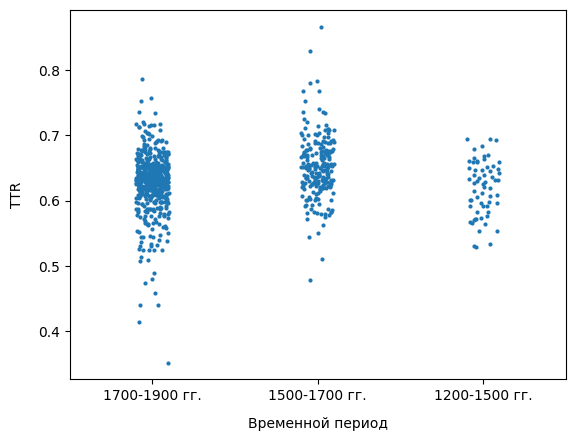

In [ ]:
sns.stripplot(data=df_selected_patterns_tokens, x='eeuw', y='ttr', jitter=True, size = 3)
plt.ylabel('TTR', labelpad=10)
plt.xlabel('Временной период', labelpad=10)
plt.show()

####4.3.3. Слова-индикаторы

Некоторые **слова** можно использовать как индикаторы для отнесения текста к определенному веку.  

В качестве примера взято слово *ende* : раньше в текстах оно использовалось в роли союза "и". В современном нидерландском языке его постепенно вытеснило *en* (см. также раздел "Дополнительно" в самом конце тетрадки об изучении частотности слова *ende* на сайте Nederlab).  

Функция **count_words** считает относительную встречаемость слова среди всех токенов текста.

In [ ]:
def count_words(list_tokens, to_find):
  count_words = 0
  for token in list_tokens:
    if token == to_find:
      count_words += 1
  count_words_rel = count_words / len(list_tokens)
  return count_words_rel

In [ ]:
df_selected_patterns_tokens['ende'] = df_selected_patterns_tokens['tokens'].progress_apply(lambda x: count_words(list_tokens = x, to_find = 'ende'))

100%|██████████| 833/833 [00:02<00:00, 317.69it/s]


In [ ]:
print(df_selected_patterns_tokens.head())

           ti_id                                               text  vrouw  \
0  _sur006179301   surinaamsche staatkundige almanach voor den j...      0   
1  _nie190nieu01   nieuw iaar lieden wt ghegheven by de nederduy...      0   
2  _vad003182901   boekbeschouwing leerredenen ter verklaring va...      0   
3  _noo007184101   de noordstar tydschrift voor letteren kunsten...      0   
4  _qua001quae01   der ix quaesten warachtighe historien als van...      0   

            eeuw  count_negations_rel         y        ae        ck        gh  \
0  1700-1900 гг.             0.000254  0.011270  0.000172  0.000561  0.000338   
1  1500-1700 гг.             0.009195  0.019882  0.012315  0.009830  0.014949   
2  1700-1900 гг.             0.003253  0.000411  0.000174  0.000075  0.000558   
3  1700-1900 гг.             0.001327  0.017874  0.013247  0.000266  0.000500   
4  1500-1700 гг.             0.018233  0.010014  0.009456  0.005066  0.007953   

        sch         z       nt         kw   

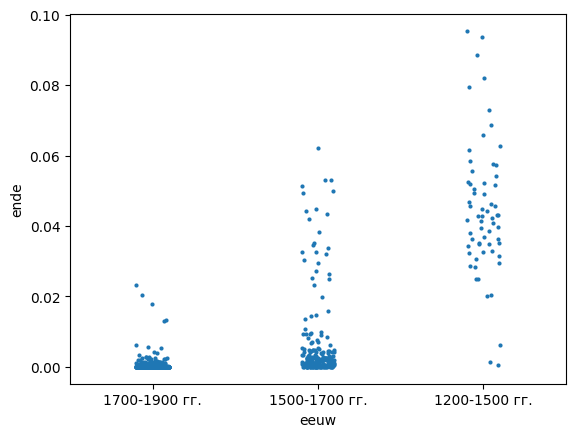

In [ ]:
sns.stripplot(data=df_selected_patterns_tokens, x='eeuw', y='ende', jitter=True, size = 3)

plt.show()

####4.3.4. Формы слов

Помимо непосредственно слов, определенные **словоформы** также могут указывать на век, в котором было издано произведение.  

Например, раньше в косвенных падежах местоимение *ik* принимало форму не *mij* (*me*), а *mi* (в винительном и дательном падеже); "ты" в косвенном падеже было *di*.

Также много словоформ оканчивалось на *-e*, в отличие от современного нидерландского языка. В частности, одним из способов образования множественного числа было прибавление к слову окончания *-e* (*dach* - *dage*). В настоящее время множественное число формируется путем прибавления *-en* либо *-s*.

Более распространены были падежные формы артиклей - *der, des, den* и другие. В современном языке они остаются в основном в устойчивых конструкциях (как в названии Гааги - den Haag).

In [ ]:
def count_bag_of_words(tokens, regex_words):
  count_all_tokens = len(tokens)
  joined_text = ' '.join(tokens)
  count_words_absolute = len(re.findall(fr'{regex_words}', joined_text))
  count_words_relative = count_words_absolute / count_all_tokens
  return count_words_relative

In [ ]:
additional_patterns = {'mi, di': r'\bmi\b|\bdi\b',
                       '-e': r'\b\w+e\b',
                       'des, der, den, ter, ten, enen, ener': r'\bdes\b|\bder\b|\bden\b|\bter\b|\bten\b|\benen\b|\bener\b'
                       }

In [ ]:
for key, value in tqdm(additional_patterns.items()):
  df_selected_patterns_tokens[key] = df_selected_patterns_tokens['tokens'].apply(lambda x: count_bag_of_words(tokens = x, regex_words = value))

100%|██████████| 3/3 [00:56<00:00, 18.84s/it]


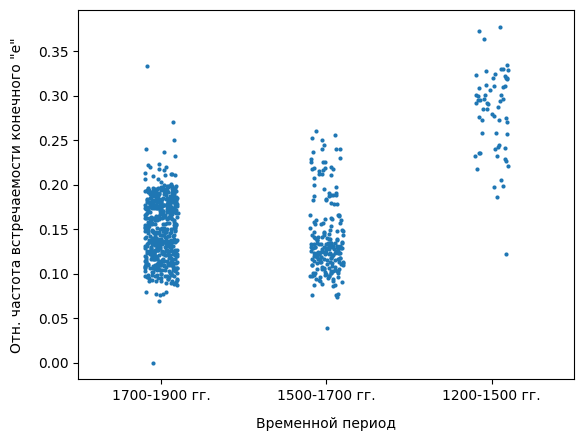

In [ ]:
sns.stripplot(data=df_selected_patterns_tokens, x='eeuw', y='-e', jitter=True, size = 3)
plt.ylabel('Отн. частота встречаемости конечного "e"', labelpad=10)
plt.xlabel('Временной период', labelpad=10)
plt.show()

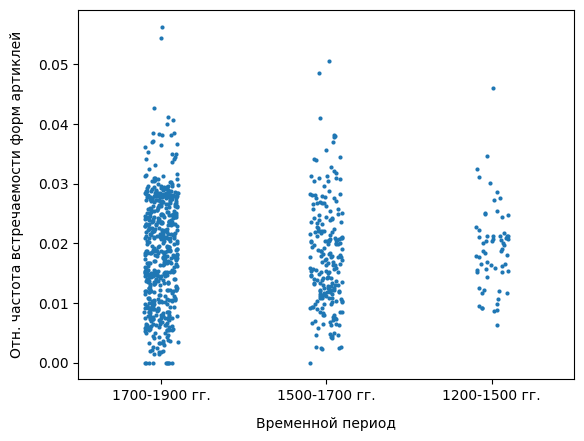

In [ ]:
sns.stripplot(data=df_selected_patterns_tokens, x='eeuw', y='des, der, den, ter, ten, enen, ener', jitter=True, size = 3)
plt.ylabel('Отн. частота встречаемости форм артиклей', labelpad=10)
plt.xlabel('Временной период', labelpad=10)
plt.show()

In [ ]:
# to_save = df_selected_patterns_tokens.drop(columns=['tokens', 'text'])

In [ ]:
# to_save.to_excel('res_without_texts_2.xlsx', index = False)

##5. Подготовка данных для обучения модели

###5.1. Отбор признаков для обучения модели

Для обучения модели важно отобрать признаки, которые характеризуются следующим:
* с одной стороны, признаки должны действительно помогать определять таргет, **коррелировать** с ним (применительно к данному проекту - век, в котором издано произведение), то есть не должны быть "шумом", мешающим модели сделать правильное предсказание;
* с другой строны, признаки между собой **не должны быть мультиколлинеарны**, иными словами, не должны сильно коррелировать друг с другом.

Для отбора признаков, отвечающих вышеназванным критериям, была построена корреляционная матрица.

По итогам ее анализа было принято решение отказаться от такого признака, как пол автора произведения, поскольку он очень мало коррелирует с таргетом (0,031).

Остальные признаки решено оставить, при этом признаки, сильно коррелирующие с таргетом, оставлены для линейных моделей, для нелинейных моделей - все признаки.

Признаков мультиколлинеарности между признаками (значения выше 0,8%) не выявлены.

In [ ]:
df_selected_patterns_tokens.columns

Index(['ti_id', 'text', 'vrouw', 'eeuw', 'count_negations_rel', 'y', 'ae',
       'ck', 'gh', 'sch', 'z', 'nt ', 'kw', 'aa', 'ee', 'oo', 'vv', 'tokens',
       'ttr', 'ende', 'mi, di', '-e', 'des, der, den, ter, ten, enen, ener'],
      dtype='object')

In [ ]:
df_for_phik = df_selected_patterns_tokens[['eeuw', 'vrouw', 'count_negations_rel', 'y', 'ae',
       'ck', 'gh', 'sch', 'z', 'nt ', 'kw', 'aa', 'ee', 'oo', 'vv',
       'ttr', 'ende', 'mi, di', '-e', 'des, der, den, ter, ten, enen, ener']]

In [ ]:
df_for_phik = df_for_phik.rename(columns={'des, der, den, ter, ten, enen, ener': 'articles_decl', 'count_negations_rel': 'neg_rel' })

interval columns not set, guessing: ['vrouw', 'neg_rel', 'y', 'ae', 'ck', 'gh', 'sch', 'z', 'nt ', 'kw', 'aa', 'ee', 'oo', 'vv', 'ttr', 'ende', 'mi, di', '-e', 'articles_decl']


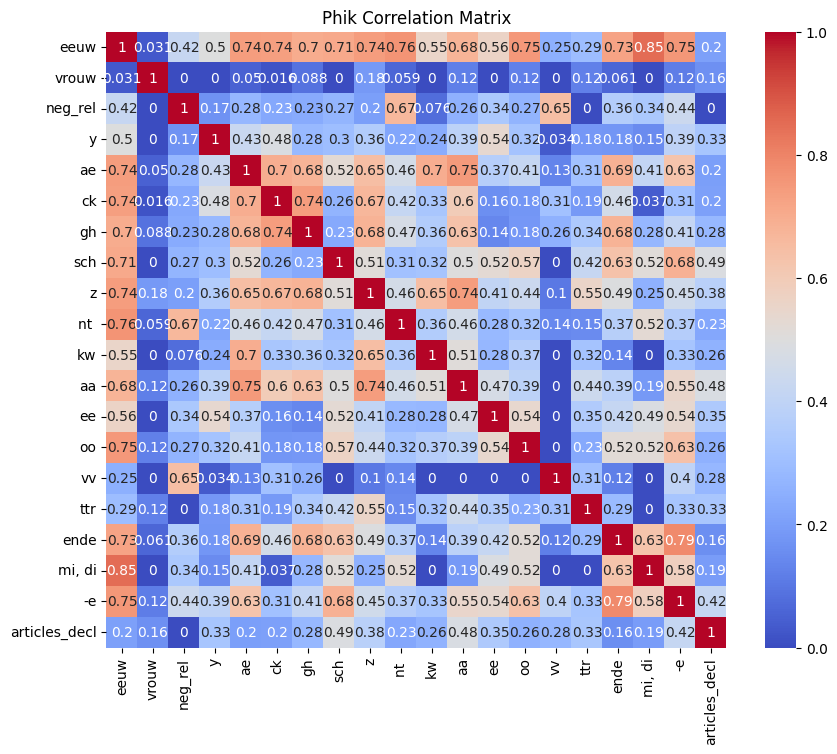

In [ ]:
phik_matrix = df_for_phik.phik_matrix()

plt.figure(figsize=(10,8))
sns.heatmap(phik_matrix, annot=True, cmap='coolwarm')
plt.title('Phik Correlation Matrix')
plt.show()

In [ ]:
linear = ['eeuw', 'y', 'ae', 'ck', 'gh', 'sch', 'z', 'kw', 'nt ', 'ee', 'oo', 'mi, di', '-e', 'aa', 'ende']

In [ ]:
linear_features = ['y', 'ae', 'ck', 'gh', 'sch', 'z', 'kw', 'nt ', 'ee', 'oo', 'mi, di', '-e', 'aa', 'ende']

In [ ]:
df_to_process_linear = df_selected_patterns_tokens[linear]

In [ ]:
nonlinear = ['eeuw', 'y', 'ae', 'ck', 'gh', 'sch', 'z', 'kw', 'nt ', 'ee', 'oo', 'mi, di', '-e', 'aa', 'ende', 'des, der, den, ter, ten, enen, ener', 'ttr', 'count_negations_rel', 'vv']

In [ ]:
nonlinear_features = ['y', 'ae', 'ck', 'gh', 'sch', 'z', 'kw', 'nt ', 'ee', 'oo', 'mi, di', '-e', 'aa', 'ende', 'des, der, den, ter, ten, enen, ener', 'ttr', 'count_negations_rel', 'vv']

In [ ]:
df_to_process_nonlinear = df_selected_patterns_tokens[nonlinear]

###5.2. Деление данных на тренировочную часть (train) и тестовую часть (test)
Данные поделены на train и test с размером тест-части в 25% и одинаковым распределением классов в train и test.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_to_process_linear[linear_features], df_to_process_linear['eeuw'], test_size=0.25, random_state=42, stratify=df_to_process_linear['eeuw'])

In [ ]:
X_train.shape

(624, 14)

In [ ]:
X_train.columns

Index(['y', 'ae', 'ck', 'gh', 'sch', 'z', 'kw', 'nt ', 'ee', 'oo', 'mi, di',
       '-e', 'aa', 'ende'],
      dtype='object')

In [ ]:
X_test.shape

(209, 14)

In [ ]:
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(df_to_process_nonlinear[nonlinear_features], df_to_process_nonlinear['eeuw'], test_size=0.25, random_state=42, stratify=df_to_process_nonlinear['eeuw'])

In [ ]:
X_train_nl.shape

(624, 18)

In [ ]:
X_test_nl.shape

(209, 18)

###5.3. Масштабирование количественных признаков
Количественные признаки масштабированы с помощью MinMaxScaler(), а не StandardScaler(), чтобы они оставались положительными и могли быть переданы в дальнейшем в том числе в модель Мультиноминального Байеса, который работает только с положительными величинами.  

Обучение скейлера проводилось на train-части данных.


In [ ]:
def to_scale(features_train, features_test):
  scaler = MinMaxScaler()
  X_train_scaled = scaler.fit_transform(features_train)
  X_test_scaled = scaler.transform(features_test)
  return X_train_scaled, X_test_scaled

In [ ]:
X_lin = to_scale(X_train, X_test)
X_nonlin = to_scale(X_train_nl, X_test_nl)

In [ ]:
X_lin[0].shape

(624, 14)

In [ ]:
X_lin[0][:1]

array([[0.00197179, 0.        , 0.        , 0.        , 0.65365355,
        0.59926718, 0.21718408, 0.08585455, 0.42725968, 0.19786165,
        0.        , 0.06425817, 0.76334691, 0.        ]])

In [ ]:
X_lin[1].shape

(209, 14)

In [ ]:
X_lin[1][:1]

array([[0.02899202, 0.30504387, 0.02559352, 0.0557582 , 0.22812296,
        0.        , 0.        , 0.47061386, 0.1309558 , 0.00119623,
        0.51637126, 0.60881642, 0.        , 0.34356495]])

###5.4. Кодирование таргета
Поскольку таргет в данном проекте - не количественная величина, он был закодирован в числа с помощью LabelEncoder().  

Обучение энкодера проводилось на train-части данных.

In [ ]:
def to_encode(target_train, target_test):
  le = LabelEncoder()
  y_train_encoded = le.fit_transform(target_train)
  y_test_encoded = le.transform(target_test)
  return y_train_encoded, y_test_encoded, le.classes_

In [ ]:
y_lin = to_encode(y_train, y_test)  #в данном случае y_lin и y_nonlin будут одинаковые, но для чистоты разделения lin/nonlin оставила разбивку
y_nonlin = to_encode(y_train_nl, y_test_nl)

In [ ]:
y_lin[2]

array(['1200-1500 гг.', '1500-1700 гг.', '1700-1900 гг.'], dtype=object)

##6. Обучение моделей и получение метрик
###6.1. Модели

Для классификации текстов по векам были опробованы несколько классических моделей:
1. Логистическая регрессия с балансом классов;
2. Мультиноминальный Байес с подсчетом баланса классов с помощью sample_weight;
3. Мультиноминальный Байес с приоритетом класса (в пользу наиболее сложно определяемого класса - второго);
4. K-ближайших соседей (со стандартными аргументами для работы с текстами, в частности косинусной метрикой);
5. Дерево решений.

В рамках функции **model_and_metrics** модель обучается, делает предсказание, и на выходе функция выдает метрики (accuracy, f1-score и полный classification report).

In [ ]:
s_weight = compute_sample_weight('balanced', y_lin[0]) #lin и nonlin одинаковые

In [ ]:
def model_and_metrics(model, x_tr, x_t, y_tr, y_t):

  model_to_use = model
  if model == MultinomialNB():
    model_to_use.fit(x_tr, y_tr, sample_weight = s_weight) #обучаем модель, если она просто мультиномиальный Байес, без priors
  else:
    model_to_use.fit(x_tr, y_tr) #обучаем модель, если она не MultinomialNB()

  y_pred = model_to_use.predict(x_t)

  accuracy = accuracy_score(y_t, y_pred) #сравниваем предсказание с настоящим значением
  f1 = f1_score(y_t, y_pred, average='weighted')

  cl = classification_report(y_t, y_pred, target_names=y_lin[2]) #lin и nonlin одинаковые

  cl_dict = classification_report(y_t, y_pred, output_dict=True, target_names=y_lin[2])

  return accuracy, f1, cl, cl_dict

In [ ]:
all_models_linear = {'Логистическая регрессия (регуляризатор - l2, Ридж, с балансом классов)': LogisticRegression(random_state=42, class_weight='balanced', max_iter=700),
              'Мультиноминальный Байес с sample_weight': MultinomialNB(),
              'Мультиноминальный Байес с приоритетом класса': MultinomialNB(class_prior=np.array([0.3, 0.4, 0.3]))}

In [ ]:
all_models_nonlinear = {'K-ближайших соседей': KNeighborsClassifier(n_neighbors=7, metric = 'cosine', weights = 'distance'), #Для K ближайших соседей попробовала взять косинусную метрику (которая подходит для работы с текстами)
                      'Decision Tree': DecisionTreeClassifier(random_state = 42, max_depth=3)}

In [ ]:
all_res_linear = {}
for key, value in tqdm(all_models_linear.items()):
  res = model_and_metrics(value, X_lin[0], X_lin[1], y_lin[0], y_lin[1])
  all_res_linear.update({key: [res[0], res[1], res[2], res[3]]})

100%|██████████| 3/3 [00:00<00:00, 20.99it/s]


In [ ]:
for_df_metrics_lin = {k: v[:-2] for k, v in all_res_linear.items()}
for_cl_all_lin = {k: v[-2:] for k, v in all_res_linear.items()}

In [ ]:
all_res_nonlinear = {}
for key, value in tqdm(all_models_nonlinear.items()):
  res = model_and_metrics(value, X_nonlin[0], X_nonlin[1], y_nonlin[0], y_nonlin[1])
  all_res_nonlinear.update({key: [res[0], res[1], res[2], res[3]]})

100%|██████████| 2/2 [00:00<00:00, 10.69it/s]


In [ ]:
for_df_metrics_nonlin = {k: v[:-2] for k, v in all_res_nonlinear.items()}
for_cl_all_nonlin = {k: v[-2:] for k, v in all_res_nonlinear.items()}

###6.2. Метрики
Все модели показали себя в разной степени хорошо, с показателями в основном более 80%.  
Тем не менее, модели стоит опробовать на большем объеме данных, чтобы избежать ошибки переобучения.

####6.2.1. Accuracy и f1-score

*Линейные модели*

In [ ]:
df_metrics_lin = pd.DataFrame.from_dict(for_df_metrics_lin).T.rename(columns={0: "Accuracy", 1: "F1-score"})

In [ ]:
# df_metrics_lin.to_excel('metrics_lin.xlsx')

In [ ]:
df_metrics_lin

,Accuracy,F1-score
"Логистическая регрессия (регуляризатор - l2, Ридж, с балансом классов)",0.909091,0.910093
Мультиноминальный Байес с sample_weight,0.928230,0.927516
Мультиноминальный Байес с приоритетом класса,0.904306,0.906079


*Нелинейные модели*

In [ ]:
df_metrics_nonlin = pd.DataFrame.from_dict(for_df_metrics_nonlin).T.rename(columns={0: "Accuracy", 1: "F1-score"})

In [ ]:
df_metrics_nonlin.to_excel('metrics_nonlin.xlsx')

In [ ]:
df_metrics_nonlin

,Accuracy,F1-score
K-ближайших соседей,0.928230,0.928301
Decision Tree,0.913876,0.914885


####6.2.2. Classification report

*Линейные модели*

In [ ]:
for_cl_lin = {k: v[:-1] for k, v in for_cl_all_lin.items()}
for_cl_df_lin = {k: v[-1:] for k, v in for_cl_all_lin.items()}

In [ ]:
for key, value in for_cl_df_lin.items():
  df = pd.DataFrame(value[0]).T
  df.to_excel(f'{key}.xlsx')

In [ ]:
for key, value in for_cl_lin.items():
  print(key)
  print()
  print(value[0])
  print()
  print('--------------------------------------------------\n')
  #в отношении Мультиномиального Байеса с priors видно, что "приоритетность" классов целесообразно скорректировать, потому что значение 0.4 создало неверный перекос для второго класса, лишь ухудшив показатели по его предсказаниям

Логистическая регрессия (регуляризатор - l2, Ридж, с балансом классов)

               precision    recall  f1-score   support

1200-1500 гг.       0.80      1.00      0.89        16
1500-1700 гг.       0.82      0.85      0.84        54
1700-1900 гг.       0.96      0.92      0.94       139

     accuracy                           0.91       209
    macro avg       0.86      0.92      0.89       209
 weighted avg       0.91      0.91      0.91       209


--------------------------------------------------

Мультиноминальный Байес с sample_weight

               precision    recall  f1-score   support

1200-1500 гг.       0.94      1.00      0.97        16
1500-1700 гг.       0.88      0.83      0.86        54
1700-1900 гг.       0.94      0.96      0.95       139

     accuracy                           0.93       209
    macro avg       0.92      0.93      0.93       209
 weighted avg       0.93      0.93      0.93       209


--------------------------------------------------

Мульт

*Нелинейные модели*

In [ ]:
for_cl_nonlin = {k: v[:-1] for k, v in for_cl_all_nonlin.items()}
for_cl_df_nonlin = {k: v[-1:] for k, v in for_cl_all_nonlin.items()}

In [ ]:
for key, value in for_cl_df_nonlin.items():
  df = pd.DataFrame(value[0]).T
  df.to_excel(f'{key}.xlsx')

In [ ]:
for key, value in for_cl_nonlin.items():
  print(key)
  print()
  print(value[0])
  print()
  print('--------------------------------------------------\n')

K-ближайших соседей

               precision    recall  f1-score   support

1200-1500 гг.       0.84      1.00      0.91        16
1500-1700 гг.       0.87      0.85      0.86        54
1700-1900 гг.       0.96      0.95      0.96       139

     accuracy                           0.93       209
    macro avg       0.89      0.93      0.91       209
 weighted avg       0.93      0.93      0.93       209


--------------------------------------------------

Decision Tree

               precision    recall  f1-score   support

1200-1500 гг.       0.93      0.88      0.90        16
1500-1700 гг.       0.81      0.89      0.85        54
1700-1900 гг.       0.96      0.93      0.94       139

     accuracy                           0.91       209
    macro avg       0.90      0.90      0.90       209
 weighted avg       0.92      0.91      0.91       209


--------------------------------------------------



##7. Ансамбли
Можно попробовать несколько улучшить отдельные метрики и повысить устойчивость моделей с помощью ансамблей.

###7.1. Стекинг
В качестве базовых моделей были выбраны Дерево решений и К-ближайших соседей, в качестве мета-модели, которая принимает окончательное решение, - логистическая регрессия.

Показатели в целом немного повысились, это хорошо видно на втором классе.

In [ ]:
base_models = [
    ('dt', DecisionTreeClassifier(random_state = 42, max_depth=3)),
    ('knn', KNeighborsClassifier(n_neighbors=7, weights = 'distance', metric = 'cosine'))
]

meta_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=700)

stacking_models = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=2,
)

In [ ]:
stacking_models.fit(X_nonlin[0], y_nonlin[0]) #для обучения возьмем все признаки, то есть те, которые выше использовались для нелинейных моделей

StackingClassifier(cv=2,
                   estimators=[('dt',
                                DecisionTreeClassifier(max_depth=3,
                                                       random_state=42)),
                               ('knn',
                                KNeighborsClassifier(metric='cosine',
                                                     n_neighbors=7,
                                                     weights='distance'))],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=700,
                                                      random_state=42))

In [ ]:
y_pred_stacking = stacking_models.predict(X_nonlin[1])

In [ ]:
print(classification_report(y_nonlin[1], y_pred_stacking, target_names=y_nonlin[2]))

               precision    recall  f1-score   support

1200-1500 гг.       0.89      1.00      0.94        16
1500-1700 гг.       0.86      0.94      0.90        54
1700-1900 гг.       0.99      0.94      0.97       139

     accuracy                           0.95       209
    macro avg       0.92      0.96      0.94       209
 weighted avg       0.95      0.95      0.95       209



In [ ]:
class_rep_2 = classification_report(y_nonlin[1], y_pred_stacking, target_names=y_nonlin[2], output_dict=True)
df = pd.DataFrame(class_rep_2).T
# df.to_excel('stacking.xlsx')

###7.2. Бустинг

####7.2.1. Адабустинг
Для адабустинга был выбран Мультиномиальный Байес с подсчетом баланса классов с помощью sample_weight. В рамках адабустинга предполагается, что каждая последующая модель нацелена на исправление ошибок предыдущей модели путем перераспределения весов.

Адабустинг помог Мультиномиальному Байесу лучше справляться в особенности с определением первого класса.

In [ ]:
adaboost_model = AdaBoostClassifier(
    estimator=MultinomialNB(),
    n_estimators=100,
    learning_rate=0.001
)

In [ ]:
adaboost_model.fit(X_lin[0], y_lin[0], sample_weight=s_weight)
y_pred_adaboost_model = adaboost_model.predict(X_lin[1])

In [ ]:
print(classification_report(y_lin[1], y_pred_adaboost_model, target_names=y_lin[2]))

               precision    recall  f1-score   support

1200-1500 гг.       0.80      1.00      0.89        16
1500-1700 гг.       0.82      0.85      0.84        54
1700-1900 гг.       0.96      0.92      0.94       139

     accuracy                           0.91       209
    macro avg       0.86      0.92      0.89       209
 weighted avg       0.91      0.91      0.91       209



In [ ]:
class_rep_4 = classification_report(y_lin[1], y_pred_adaboost_model, target_names=y_lin[2], output_dict = True)
df = pd.DataFrame(class_rep_4).T
# df.to_excel('adaboosting.xlsx')

####7.2.2. Градиентный бустинг

В основе градиентного бустинга - деревья решений. Суть ансамбля та же, что и в адабустинге - корректировка модели после каждого предсказания.

Градиентный бустинг показал улучшение результата работы дерева решений по всем классам.

In [ ]:
boosting = GradientBoostingClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 7)

In [ ]:
boosting.fit(X_nonlin[0], y_nonlin[0])
y_pred_boosting = boosting.predict(X_nonlin[1])

In [ ]:
print(classification_report(y_nonlin[1], y_pred_boosting, target_names=y_nonlin[2]))

               precision    recall  f1-score   support

1200-1500 гг.       1.00      0.94      0.97        16
1500-1700 гг.       0.85      0.93      0.88        54
1700-1900 гг.       0.97      0.94      0.96       139

     accuracy                           0.94       209
    macro avg       0.94      0.94      0.94       209
 weighted avg       0.94      0.94      0.94       209



In [ ]:
class_rep_5 = classification_report(y_nonlin[1], y_pred_boosting, target_names=y_nonlin[2], output_dict = True)
df = pd.DataFrame(class_rep_5).T
# df.to_excel('boosting.xlsx')

###Дополнительно: работа с данными с сайта Nederlab

Для того чтобы определить, может ли слово *ende* (обозначало раньше в нидерландском союз "и") быть хорошим показателем века, в котором издано произведение, данные о частотности этого слова в корпусе DBNL были изучены с помощью сервиса на сайте [Nederlab](https://www.nederlab.nl/onderzoeksportaal/?action=verkennen).

Для неавторизованных пользователей на сайте есть возможность выгрузить сырые данные (в формате .csv) - в частности, **количество случаев, когда конкретное слово встретилось в корпусе в конкретном году** (*hits*).

Чтобы посчитать относительную частотность конкретного слова в корпусе в конкретном году, с сайта были также выгружены сырые данные **о количестве просто всех слов в корпусе в конкретном году** (такая возможность есть на сайте, задав поиск по всем словам в корпусе с помощью регулярных выражений).

Функция **transform_dataframe** переводит таблицу, выгружаемую с сайта Nederlab, в "широкий" формат, чистит таблицу от лишних знаков, переводит значения из строкового формата в числовой и добавляет в таблицу колонку с разбивкой на временные периоды.

In [ ]:
def transform_dataframe(df):
  df_wide = df.pivot(index=' "key"', columns='type', values=' "value"').reset_index()
  df_wide_corr = df_wide.replace('"', '', regex=True)
  df_wide_corr = df_wide_corr.replace(' ', '', regex=True)
  df_wide_num = df_wide_corr.apply(pd.to_numeric, errors='coerce')
  for_column_year = [
    (df_wide_num[' "key"'] < 1500, '1200-1500 гг.'),
    (df_wide_num[' "key"'] < 1700, '1500-1700 гг.'),
    (df_wide_num[' "key"'] < 1900, '1700-1900 гг.')]
  df_wide_num['eeuw'] = df_wide_num[' "key"'].case_when(caselist=for_column_year)
  # df_wide_num['sum_hits'] = df_wide_num.groupby('eeuw')['hits'].transform('sum')
  return df_wide_num

*Таблица с данными по слову ende*

In [ ]:
vis = pd.read_csv('/content/json_download_vis-timeline_NIEUW.csv')

In [ ]:
vis_with_eeuw = transform_dataframe(vis)

In [ ]:
vis_with_eeuw.head()

type,"""key""",documenten,hits,eeuw
0,1275,2,1182,1200-1500 гг.
1,1340,1,506,1200-1500 гг.
2,1374,1,1070,1200-1500 гг.
3,1400,6,797,1200-1500 гг.
4,1401,1,53,1200-1500 гг.


In [ ]:
vis_with_eeuw.shape

(461, 4)

*Таблица с данными по всем словам*

In [ ]:
vis_2 = pd.read_csv('/content/json_download_vis-timeline_ALL.csv')

In [ ]:
vis_with_eeuw_2 = transform_dataframe(vis_2)

In [ ]:
vis_with_eeuw_2.head()

type,"""key""",documenten,hits,eeuw
0,1275,2,263134,1200-1500 гг.
1,1340,1,17222,1200-1500 гг.
2,1374,1,39486,1200-1500 гг.
3,1400,6,32484,1200-1500 гг.
4,1401,1,36301,1200-1500 гг.


In [ ]:
vis_with_eeuw_2 = vis_with_eeuw_2.drop(columns=['documenten', 'eeuw'])

In [ ]:
vis_with_eeuw_2_renamed = vis_with_eeuw_2.rename(columns={'hits': 'hits_2'})

In [ ]:
vis_with_eeuw_2_renamed.head()

type,"""key""",hits_2
0,1275,263134
1,1340,17222
2,1374,39486
3,1400,32484
4,1401,36301


In [ ]:
vis_with_eeuw_2_renamed.shape

(469, 2)

*Соединение двух таблиц*

In [ ]:
merged_vis = pd.merge(vis_with_eeuw, vis_with_eeuw_2_renamed, on=' "key"', how='inner')

In [ ]:
merged_vis.head()

type,"""key""",documenten,hits,eeuw,hits_2
0,1275,2,1182,1200-1500 гг.,263134
1,1340,1,506,1200-1500 гг.,17222
2,1374,1,1070,1200-1500 гг.,39486
3,1400,6,797,1200-1500 гг.,32484
4,1401,1,53,1200-1500 гг.,36301


*Подсчет общего количества слова ende и всех слов по временным периодам*

In [ ]:
merged_vis['sum_hits_ende'] = merged_vis.groupby('eeuw')['hits'].transform('sum')

In [ ]:
merged_vis['sum_hits_all'] = merged_vis.groupby('eeuw')['hits_2'].transform('sum')

In [ ]:
merged_vis_clean = merged_vis.drop_duplicates(subset='eeuw')

In [ ]:
merged_vis_clean = merged_vis_clean.head(3)

In [ ]:
merged_vis_clean

type,"""key""",documenten,hits,eeuw,hits_2,sum_hits_ende,sum_hits_all
0,1275,2,1182,1200-1500 гг.,263134,72611,1497433
11,1500,1,761,1500-1700 гг.,32212,534090,38884983
151,1700,17,1915,1700-1900 гг.,733354,462745,284083083


*Подсчет относительной встречаемости слова ende по временным периодам*

In [ ]:
merged_vis_clean['rel_num'] = merged_vis_clean['sum_hits_ende'] / merged_vis_clean['sum_hits_all']

In [ ]:
merged_vis_clean.isna().any()

,0
type,
"""key""",False
documenten,False
hits,False
eeuw,False
hits_2,False
sum_hits_ende,False
sum_hits_all,False
rel_num,False


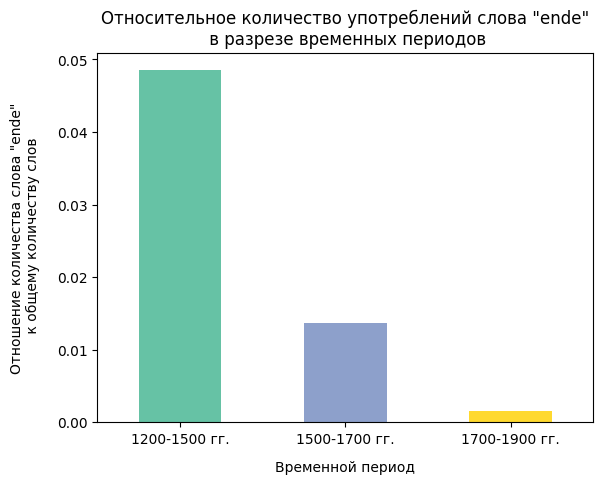

In [ ]:
cmap_3 = plt.get_cmap('Set2')
bar_colors = [cmap_3(i / len(merged_vis_clean['eeuw'])) for i in range(len(merged_vis_clean['eeuw']))]

merged_vis_clean.plot(x='eeuw', y='rel_num', kind='bar', legend=False, color=bar_colors)

plt.title('Относительное количество употреблений слова "ende"\n в разрезе временных периодов')
plt.xlabel('Временной период', labelpad=10)
plt.ylabel('Отношение количества слова "ende"\n к общему количеству слов', labelpad=12)
plt.xticks(rotation=0)
plt.show()